<h1> SVM (Support Vector Machine)

The Kernel Trick Idea

Idea:
Map the data to a higher-dimensional space to make it linearly separable.

For example:

Original space:

$x=(x_1,x_2)$

Transform to:

$\phi(x)=
(x_1,x_2,x_1^2,x_2^2,x_1x_2)
$

What is the problem with this transformation?

If there are many features—
for example,

$1000$

features—

a direct transformation can become very computationally expensive.
This is where the kernel trick comes in.

In [47]:
import matplotlib.pyplot as plt
import numpy as np

from sklearn.datasets import make_moons

from sklearn.svm import SVC

from sklearn.metrics import accuracy_score


<h3> Step 1: Making the Dataset

In [48]:
X, y = make_moons(
    n_samples=200,
    noise=0.15,
    random_state=42
)

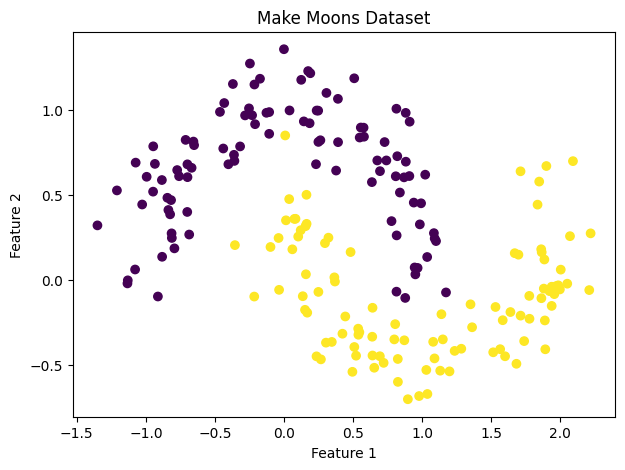

In [49]:
plt.figure(
    figsize=(7,5)
)

plt.scatter(
    X[:,0],
    X[:,1],
    c=y
)

plt.title(
    "Make Moons Dataset"
)

plt.xlabel(
    "Feature 1"
)

plt.ylabel(
    "Feature 2"
)

plt.show()

<h3> Step 2: Linear Kernel

In [50]:
linear_svm = SVC(
    kernel="linear",
    C=1
)

linear_svm.fit(
    X,
    y
)

y_pred = linear_svm.predict(
    X
)

accuracy = accuracy_score(
    y,
    y_pred
)

print(
    accuracy
)

0.845


This means the model correctly classified approximately 84.5% of the samples.
This result is not bad, but it indicates that the model still has limitations.

In [51]:
def plot_decision_boundary(
    model,
    X,
    y,
    title
):

    x_min = X[:,0].min()-1
    x_max = X[:,0].max()+1

    y_min = X[:,1].min()-1
    y_max = X[:,1].max()+1


    xx, yy = np.meshgrid(
        np.linspace(
            x_min,
            x_max,
            300
        ),
        np.linspace(
            y_min,
            y_max,
            300
        )
    )

    Z = model.predict(
        np.c_[
            xx.ravel(),
            yy.ravel()
        ]
    )

    Z = Z.reshape(
        xx.shape
    )

    plt.figure(
        figsize=(7,5)
    )

    plt.contourf(
        xx,
        yy,
        Z,
        alpha=0.3
    )

    plt.scatter(
        X[:,0],
        X[:,1],
        c=y
    )

    plt.title(
        title
    )

    plt.show()

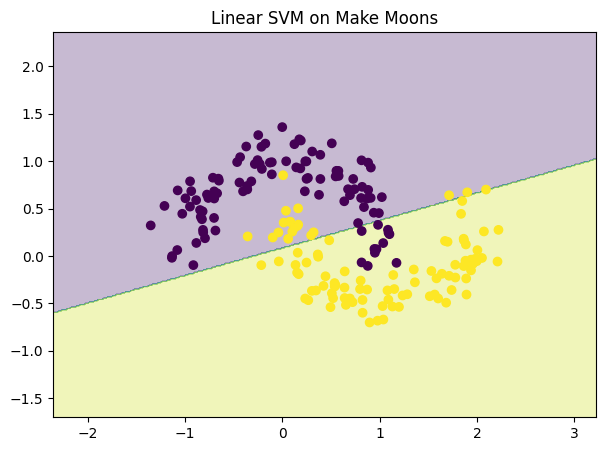

In [52]:
plot_decision_boundary(
    linear_svm,
    X,
    y,
    "Linear SVM on Make Moons"
)

The main issue with the chart
In the chart, we see:
- The SVM has created a straight line.
- However, the data structure is crescent-shaped.
- The two classes cannot be completely separated by a straight line in the current space.

### Linear SVM Limitation on Non-linear Data

A Linear SVM was applied to the Make Moons dataset to demonstrate the limitation of linear decision boundaries.

The model achieved an accuracy of 84.5%, but the visualization shows that a straight hyperplane cannot correctly separate the two classes.

Since the data structure is non-linear, a more flexible approach is required.

Kernel methods solve this problem by implicitly mapping data into a higher-dimensional feature space where linear separation becomes possible.

<h3> Step 3: Polynomial Kernel

In a linear SVM, the model learns only:

$w_1x_1+w_2x_2+b=0$

However, a polynomial kernel effectively creates new features.

In [53]:
poly_svm = SVC(
    kernel="poly",
    degree=3,
    C=1
)

poly_svm.fit(
    X,
    y
)

poly_pred = poly_svm.predict(
    X
)

poly_accuracy = accuracy_score(
    y,
    poly_pred
)

print(
    poly_accuracy
)

0.925


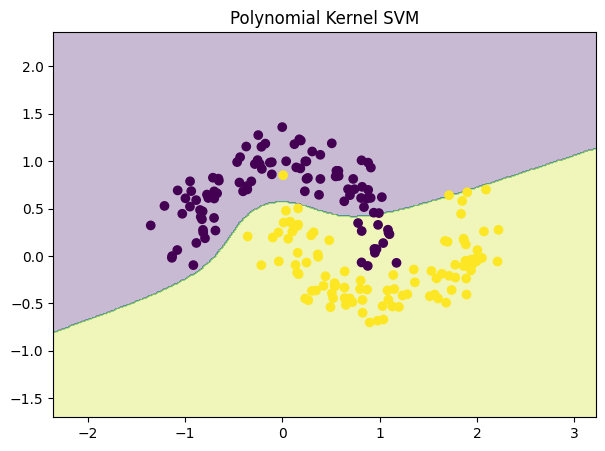

In [54]:
plot_decision_boundary(
    poly_svm,
    X,
    y,
    "Polynomial Kernel SVM"
)

<h3> Coparing 3 Degrees

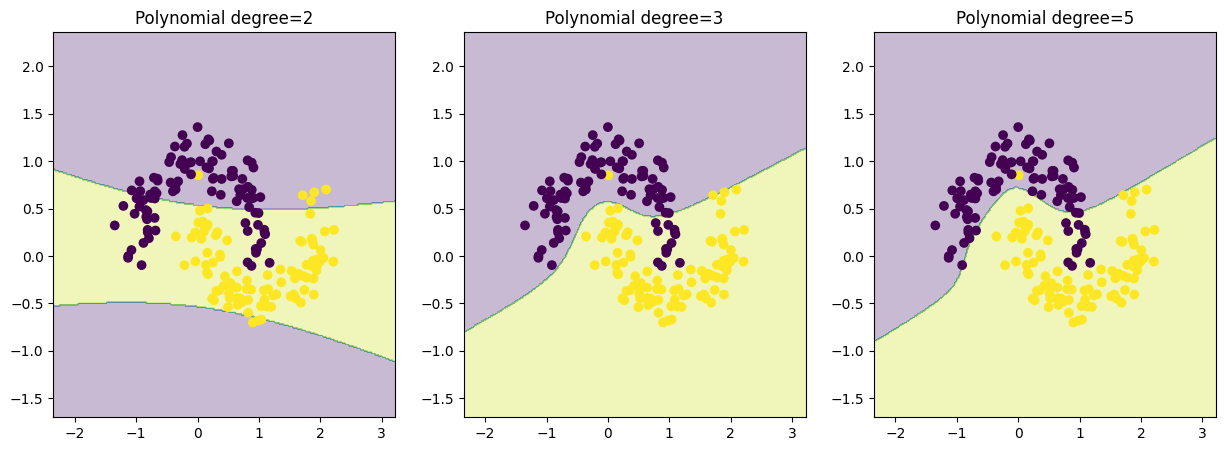

In [55]:
degrees = [
    2,
    3,
    5
]

fig, axes = plt.subplots(
    1,
    3,
    figsize=(15,5)
)

for ax, degree in zip(
    axes,
    degrees
):

    model = SVC(
        kernel="poly",
        degree=degree,
        C=1
    )

    model.fit(
        X,
        y
    )

    x_min, x_max = X[:,0].min()-1, X[:,0].max()+1
    y_min, y_max = X[:,1].min()-1, X[:,1].max()+1

    xx, yy = np.meshgrid(
        np.linspace(x_min,x_max,300),
        np.linspace(y_min,y_max,300)
    )

    Z = model.predict(
        np.c_[
            xx.ravel(),
            yy.ravel()
        ]
    ).reshape(
        xx.shape
    )

    ax.contourf(
        xx,
        yy,
        Z,
        alpha=0.3
    )

    ax.scatter(
        X[:,0],
        X[:,1],
        c=y
    )

    ax.set_title(
        f"Polynomial degree={degree}"
    )

plt.show()

### Polynomial Kernel SVM

A Polynomial Kernel was applied to the Make Moons dataset to handle the non-linear relationship between classes.

Unlike Linear SVM, the Polynomial Kernel creates a non-linear decision boundary by implicitly mapping the data into a higher-dimensional feature space.

#### Results

- Linear SVM accuracy: 0.845
- Polynomial Kernel accuracy: 0.925

The Polynomial Kernel improved classification performance by learning a curved decision boundary.

#### Effect of Degree

- Degree=2:
  - Simpler boundary
  - May underfit complex patterns

- Degree=3:
  - Better balance between flexibility and generalization

- Degree=5:
  - More complex boundary
  - Higher risk of overfitting

#### Conclusion

Polynomial Kernel allows SVM to solve non-linear classification problems without explicitly creating additional features.

<h3> Step 5: RBF Kernel (Radial Basis Function)

The RBF is the most important and widely used kernel in SVM.
Objective:
- Creating highly flexible boundaries
- Examining the effect of gamma
- Understanding the relationship between model complexity and overfitting

The RBF Kernel Concept
Formula:

$K(x_i,x_j)=e^{-\gamma ||x_i-x_j||^2}$

Simple concept:

RBF assesses:
How similar are two points to each other?

#### The Role of Gamma

It controls how sensitive the model is to nearby points.

Low Gamma

gamma=0.1

The model:
- Considers more points.
- Produces a smoother boundary.
- Has lower complexity.

High Gamma

gamma=10

The model:
- Considers only very close neighbors.
- Produces a more complex boundary.
- Increases the risk of overfitting.

In [56]:
rbf_svm = SVC(
    kernel="rbf",
    C=1,
    gamma=1
)

rbf_svm.fit(
    X,
    y
)

rbf_pred = rbf_svm.predict(
    X
)

rbf_accuracy = accuracy_score(
    y,
    rbf_pred
)

print(
    rbf_accuracy
)

0.98


Accuracy Analysis

Accuracy = 0.98

This means the model performed correctly about 98% of the time on this dataset.

If there were 100 samples, it implies that only about 2 samples were misclassified.

This is an excellent result, demonstrating that:
- The non-linear decision boundary was effectively learned.
- RBF performs much better than Linear SVM for a dataset like `make_moons`.
- The model successfully captured the curved structure of the data.

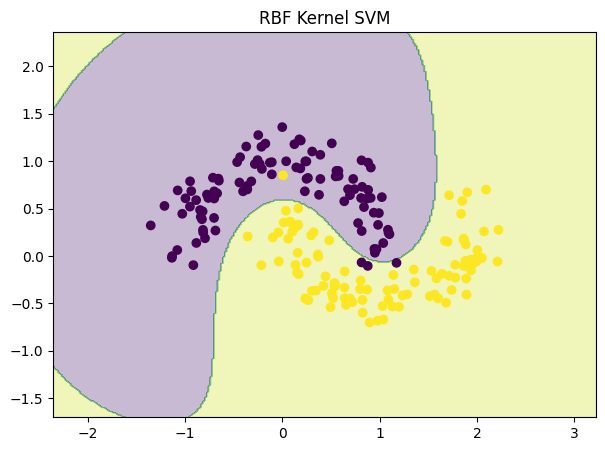

In [57]:
plot_decision_boundary(
    rbf_svm,
    X,
    y,
    "RBF Kernel SVM"
)

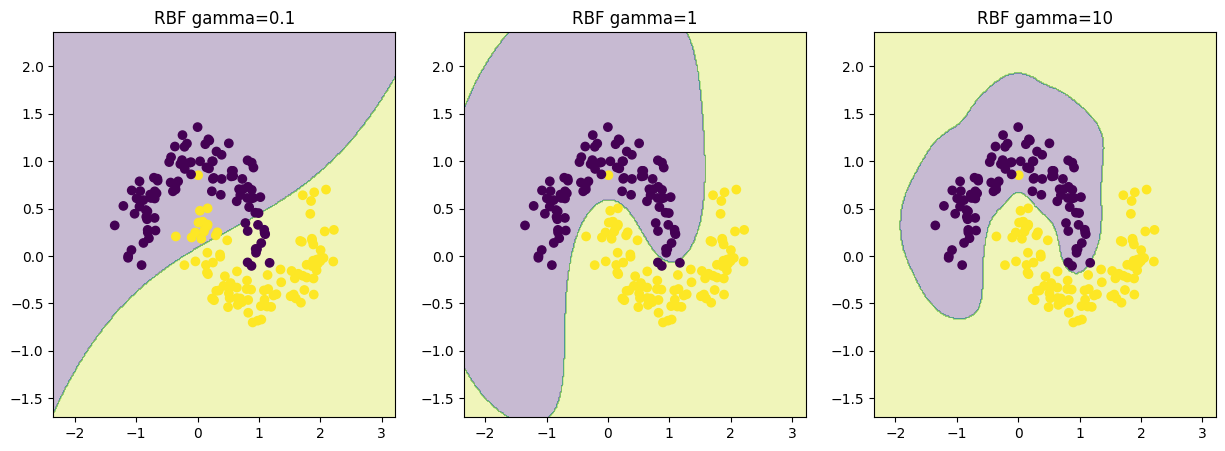

In [58]:
gammas = [
    0.1,
    1,
    10
]

fig, axes = plt.subplots(
    1,
    3,
    figsize=(15,5)
)

for ax, gamma in zip(
    axes,
    gammas
):

    model = SVC(
        kernel="rbf",
        C=1,
        gamma=gamma
    )

    model.fit(
        X,
        y
    )

    x_min, x_max = X[:,0].min()-1, X[:,0].max()+1
    y_min, y_max = X[:,1].min()-1, X[:,1].max()+1

    xx, yy = np.meshgrid(
        np.linspace(
            x_min,
            x_max,
            300
        ),
        np.linspace(
            y_min,
            y_max,
            300
        )
    )

    Z = model.predict(
        np.c_[
            xx.ravel(),
            yy.ravel()
        ]
    ).reshape(
        xx.shape
    )

    ax.contourf(
        xx,
        yy,
        Z,
        alpha=0.3
    )

    ax.scatter(
        X[:,0],
        X[:,1],
        c=y
    )

    ax.set_title(
        f"RBF gamma={gamma}"
    )

plt.show()

### Analysis of the first plot: RBF Kernel SVM

In the first figure, the decision boundary has become completely non-linear and curves effectively around one of the classes.

Insights from the plot:
- The classes are no longer separated by a straight line.
- The model has grasped the crescent-like structure of the data.
- Unlike Linear SVM, the decision boundary here aligns better with the actual shape of the data.


#### Conclusion:
The RBF kernel has successfully achieved what kernel methods were designed for:
Transforming a non-linear problem into one that is separable in a new feature space.

### Analysis of the second plot: Comparing gamma values

1) gamma = 0.1

In this case, the decision boundary is smoother and more generalized.
Characteristics:
- The model does not operate in a highly localized manner.
- The regions are smoother.
- Model complexity is lower.

Takeaway:
- This setting usually offers better generalization.
- However, if the value becomes too low, the model might slightly underfit.
Performance remains good in your plot, though the boundary is simpler compared to the subsequent cases.

2) gamma = 1

This appears to be the most balanced setting.
Characteristics:
- The decision boundary curves effectively.
- It captures the true structure of the data.
- It is neither overly simple nor overly complex.

Takeaway:
This is typically the range where the model:
- Fits well.
- Does not yet overfit.
Given that your accuracy reached 0.98, it is clear that this was an excellent choice.

3) gamma = 10

Here, the decision boundary has become much more localized and complex. Characteristics:
- The model is more sensitive to nearby points.
- The decision boundary captures more detail.
- The shape of the boundary becomes somewhat more convoluted.

Interpretation:</br>
This state may signal the onset of overfitting, as the model is adhering too closely to the precise form of the data.</br>
While the model hasn't completely failed in this plot, the boundary is noticeably more complex compared to the gamma=1 case.

#### Conceptual Summary
These outputs clearly demonstrate that:
- Linear SVM is insufficient for non-linear data.
- Polynomial Kernel offers some improvement.
- RBF Kernel provides the greatest flexibility for this type of data.
- The gamma parameter directly influences the complexity of the decision boundary.

<h3> Step 6: Final Comparison: Kernel Methods

In [59]:
models = {
    "Linear SVM": SVC(
        kernel="linear",
        C=1
    ),

    "Polynomial SVM": SVC(
        kernel="poly",
        degree=3,
        C=1
    ),

    "RBF SVM": SVC(
        kernel="rbf",
        gamma=1,
        C=1
    )
}

results = {}

for name, model in models.items():

    model.fit(
        X,
        y
    )

    predictions = model.predict(
        X
    )

    results[name] = accuracy_score(
        y,
        predictions
    )

results

{'Linear SVM': 0.845, 'Polynomial SVM': 0.925, 'RBF SVM': 0.98}

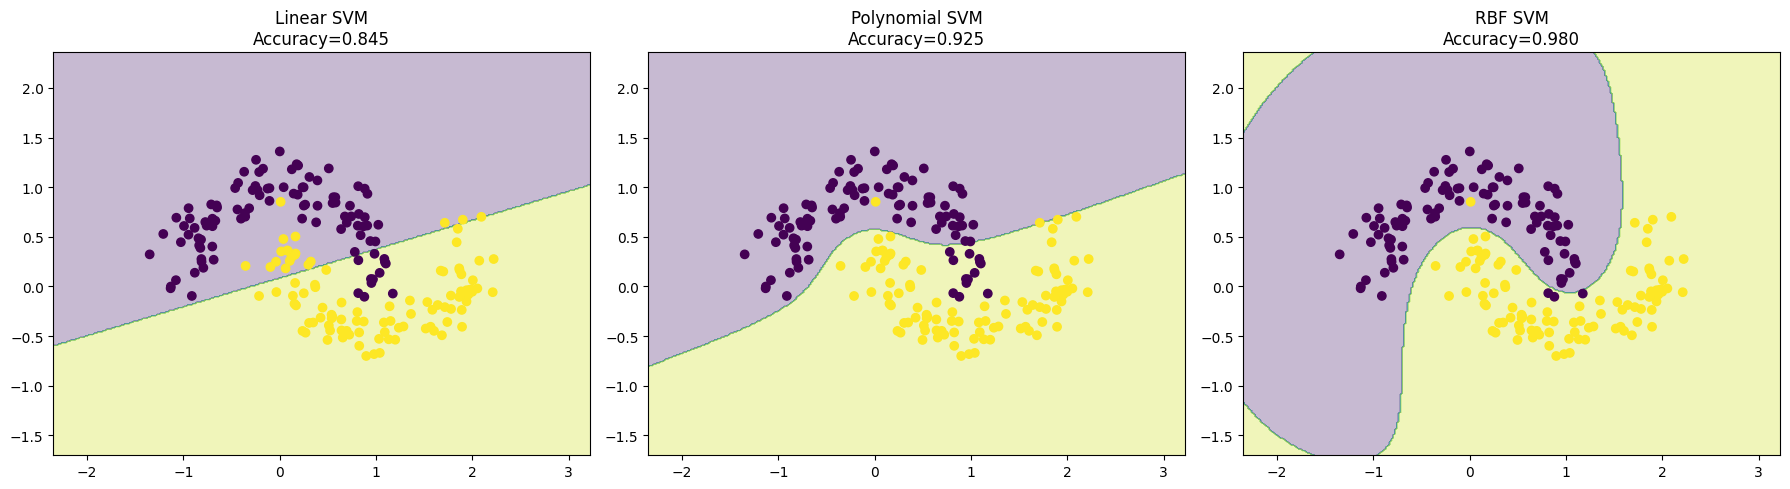

In [60]:
fig, axes = plt.subplots(
    1,
    3,
    figsize=(18,5)
)


for ax, (name, model) in zip(
    axes,
    models.items()
):

    x_min, x_max = X[:,0].min()-1, X[:,0].max()+1
    y_min, y_max = X[:,1].min()-1, X[:,1].max()+1


    xx, yy = np.meshgrid(
        np.linspace(
            x_min,
            x_max,
            300
        ),
        np.linspace(
            y_min,
            y_max,
            300
        )
    )


    Z = model.predict(
        np.c_[
            xx.ravel(),
            yy.ravel()
        ]
    )


    Z = Z.reshape(
        xx.shape
    )


    ax.contourf(
        xx,
        yy,
        Z,
        alpha=0.3
    )


    ax.scatter(
        X[:,0],
        X[:,1],
        c=y
    )


    ax.set_title(
        f"{name}\nAccuracy={results[name]:.3f}"
    )


plt.tight_layout()
plt.show()

### Final Comparison of Kernel Methods

Three SVM approaches were compared on a nonlinear dataset:

- Linear Kernel
- Polynomial Kernel
- RBF Kernel

#### Observations

The Linear SVM created a straight decision boundary and achieved lower performance because the dataset was not linearly separable.

The Polynomial Kernel improved the results by creating a nonlinear boundary through an implicit feature transformation.

The RBF Kernel achieved the best performance by learning a flexible nonlinear decision boundary based on similarity between samples.

#### Conclusion

Kernel methods allow SVM to solve nonlinear classification problems without explicitly creating high-dimensional features.

The choice of kernel and parameters such as `degree` and `gamma` controls the complexity of the decision boundary and the balance between underfitting and overfitting.